In [1]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")



### Observation

All the required libraries have been imported successfully.

These libraries will be used for data manipulation, visualization, feature scaling, and customer segmentation using the K-Means clustering algorithm.

In [2]:
# Load Dataset

df = pd.read_csv("data/Mall_Customers.csv")

print("Dataset Loaded Successfully!")

df.head()

Dataset Loaded Successfully!


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Observation

The customer dataset has been loaded successfully.

The first five records provide an overview of customer information including Customer ID, Gender, Age, Annual Income, and Spending Score.

In [3]:
# Dataset Overview

print("Dataset Shape :", df.shape)

print("\nRows :", df.shape[0])

print("Columns :", df.shape[1])

df.info()

Dataset Shape : (200, 5)

Rows : 200
Columns : 5
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


### Observation

The dataset overview provides information about the total number of customer records, available features, and their respective data types.

This helps in understanding the structure of the dataset before performing preprocessing and clustering.

In [4]:
# Missing Values

missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": (df.isnull().sum()/len(df)*100).round(2)
})

missing_values

,Missing Values,Percentage (%)
CustomerID,0,0.0
Gender,0,0.0
Age,0,0.0
Annual Income (k$),0,0.0
Spending Score (1-100),0,0.0


### Observation

The dataset contains no missing values.

Since all customer records are complete, no additional preprocessing is required for handling null values.

# Duplicate Records

duplicates = df.duplicated().sum()

print("Total Duplicate Records :", duplicates)

### Observation

The dataset does not contain duplicate records.

Each customer record is unique, ensuring accurate customer segmentation.

In [6]:
# Data Types

datatype_df = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str)
})

datatype_df

,Column,Data Type
CustomerID,CustomerID,int64
Gender,Gender,str
Age,Age,int64
Annual Income (k$),Annual Income (k$),int64
Spending Score (1-100),Spending Score (1-100),int64


### Observation

The dataset consists of both categorical and numerical features.

The Gender column is categorical, while Age, Annual Income, and Spending Score are numerical variables suitable for clustering after preprocessing.

In [8]:
# Statistical Summary

df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


### Observation

The statistical summary provides descriptive statistics such as mean, standard deviation, minimum, maximum, and quartile values for all numerical features.

These statistics help understand the overall distribution of customer attributes before segmentation.

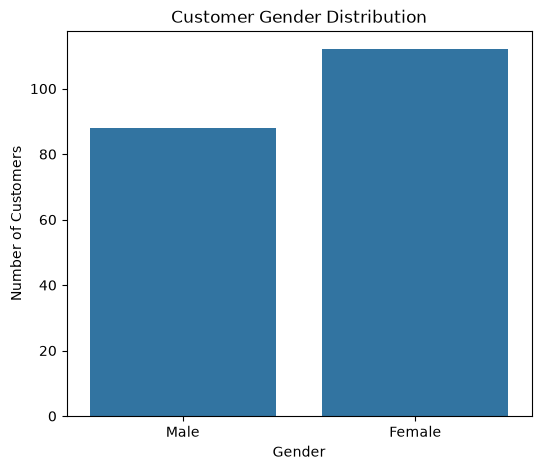

In [9]:
# Customer Gender Distribution

plt.figure(figsize=(6,5))

sns.countplot(x="Gender", data=df)

plt.title("Customer Gender Distribution")

plt.xlabel("Gender")

plt.ylabel("Number of Customers")

plt.show()

### Observation

The chart shows the distribution of male and female customers in the dataset.

This helps understand the overall customer composition and identify whether the dataset is balanced across gender groups.

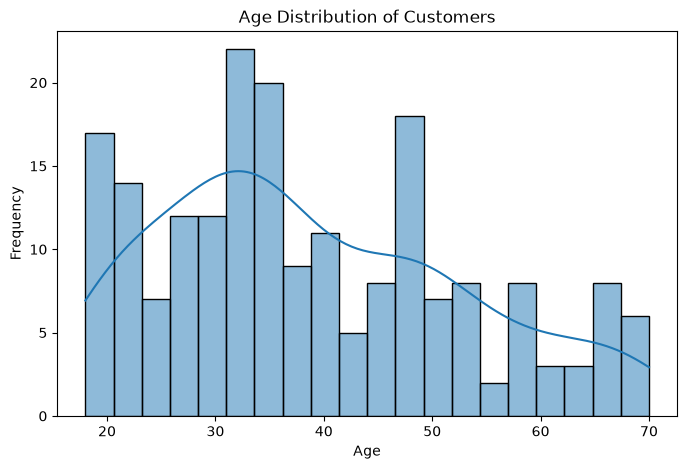

In [10]:
# Age Distribution

plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Age Distribution of Customers")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.show()

### Observation

The age distribution illustrates how customers are spread across different age groups.

It helps identify the most common customer age range and understand the demographic profile of the customers.

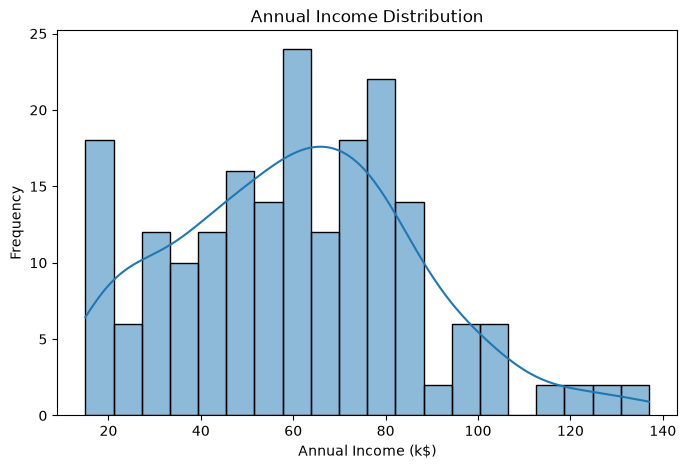

In [11]:
# Annual Income Distribution

plt.figure(figsize=(8,5))

sns.histplot(df["Annual Income (k$)"], bins=20, kde=True)

plt.title("Annual Income Distribution")

plt.xlabel("Annual Income (k$)")

plt.ylabel("Frequency")

plt.show()

### Observation

The distribution of annual income provides insights into the income levels of customers.

Understanding income variation is useful for identifying potential customer groups during segmentation.

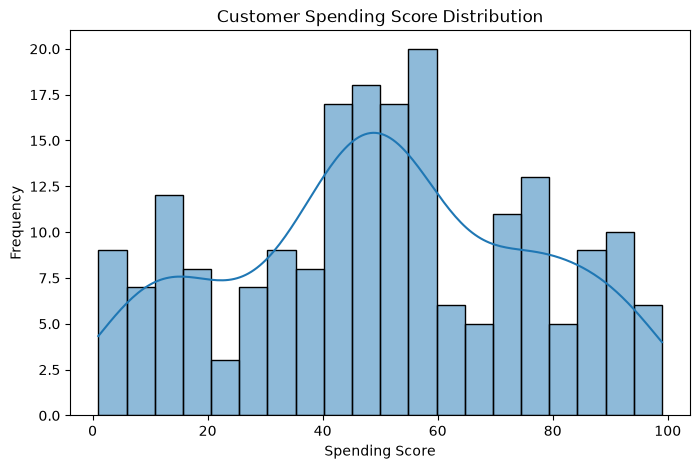

In [12]:
# Spending Score Distribution

plt.figure(figsize=(8,5))

sns.histplot(df["Spending Score (1-100)"], bins=20, kde=True)

plt.title("Customer Spending Score Distribution")

plt.xlabel("Spending Score")

plt.ylabel("Frequency")

plt.show()

### Observation

The spending score distribution shows customer purchasing behavior.

Customers with higher spending scores are generally more active shoppers, while lower scores indicate lower purchasing activity.

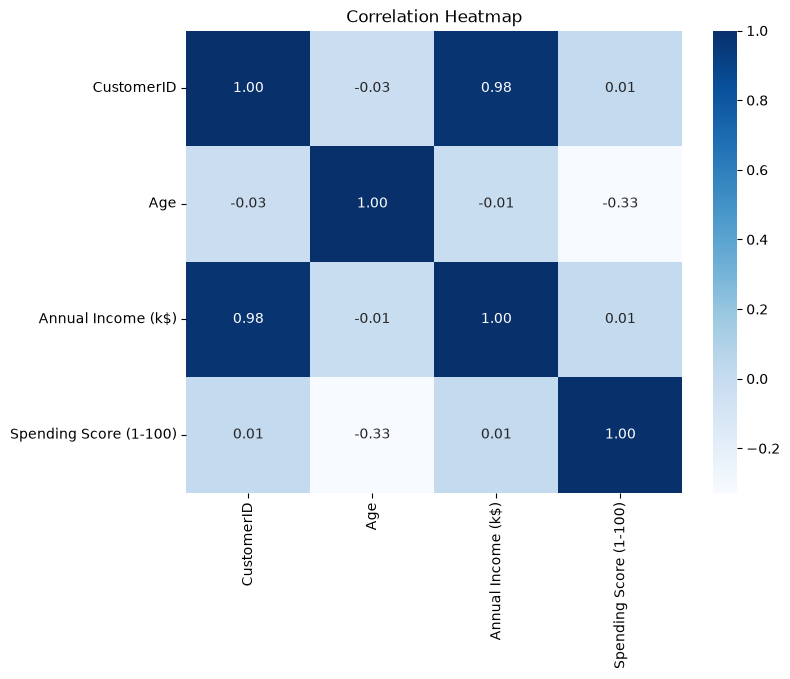

In [13]:
# Correlation Heatmap

plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=["number"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

The correlation heatmap illustrates the relationships between numerical features.

It helps identify whether strong linear relationships exist among age, annual income, and spending score before applying clustering.

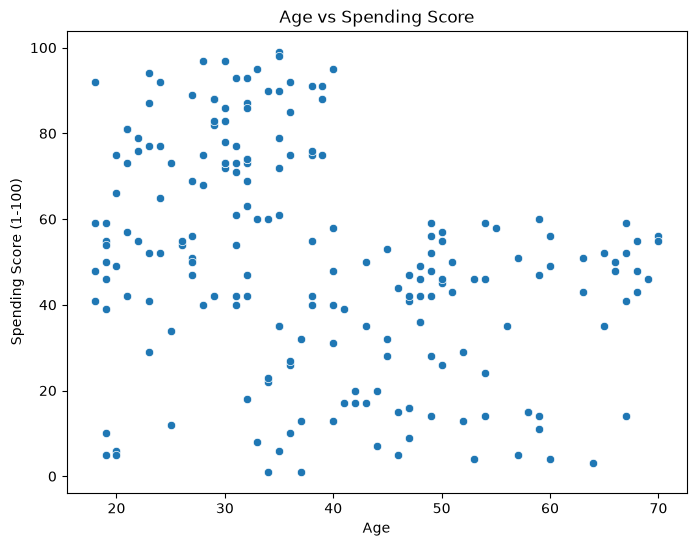

In [14]:
# Age vs Spending Score

plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Age",
    y="Spending Score (1-100)",
    data=df
)

plt.title("Age vs Spending Score")

plt.show()

### Observation

This scatter plot shows the relationship between customer age and spending score.

It provides an initial view of possible customer groups before clustering.

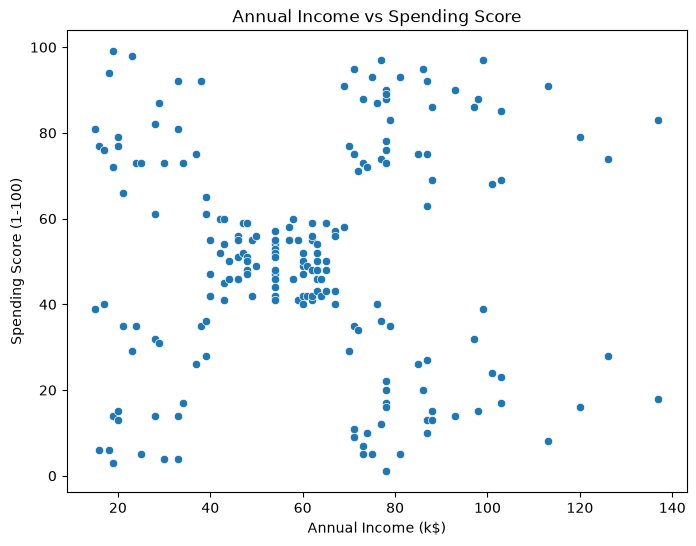

In [15]:
# Annual Income vs Spending Score

plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    data=df
)

plt.title("Annual Income vs Spending Score")

plt.show()

### Observation

The scatter plot highlights the relationship between annual income and spending score.

Distinct customer group patterns can already be observed, making these features suitable for K-Means clustering.

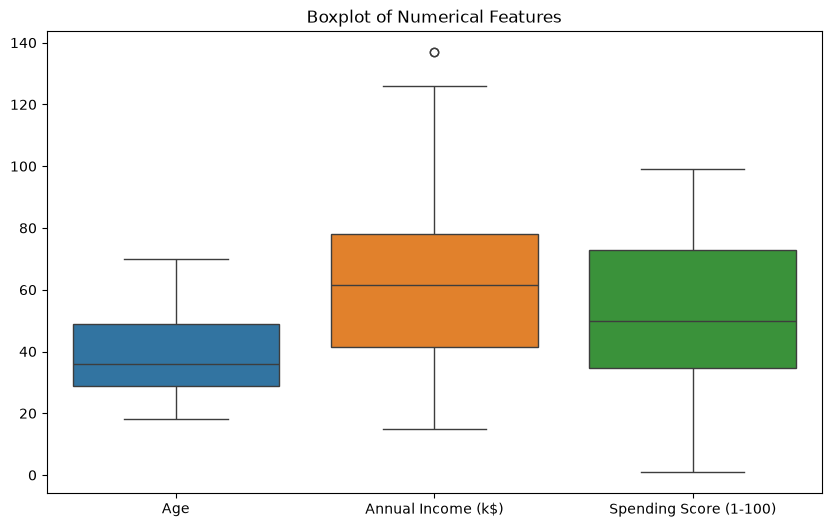

In [16]:
# Boxplots of Numerical Features

plt.figure(figsize=(10,6))

sns.boxplot(data=df[["Age",
                     "Annual Income (k$)",
                     "Spending Score (1-100)"]])

plt.title("Boxplot of Numerical Features")

plt.show()

### Observation

The boxplots summarize the distribution of the numerical features and highlight potential outliers.

This visualization helps assess data spread before feature scaling and clustering.

In [17]:
# Feature Selection

X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


### Observation

Only **Annual Income** and **Spending Score** have been selected for clustering.

These features best represent customer purchasing behavior and help create meaningful customer segments.

In [18]:
# Feature Scaling

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature Scaling Completed Successfully!")

X_scaled

Feature Scaling Completed Successfully!


array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

### Observation

Feature scaling has been applied using the **StandardScaler**.

Scaling ensures that Annual Income and Spending Score have equal importance during distance calculations in the K-Means algorithm.

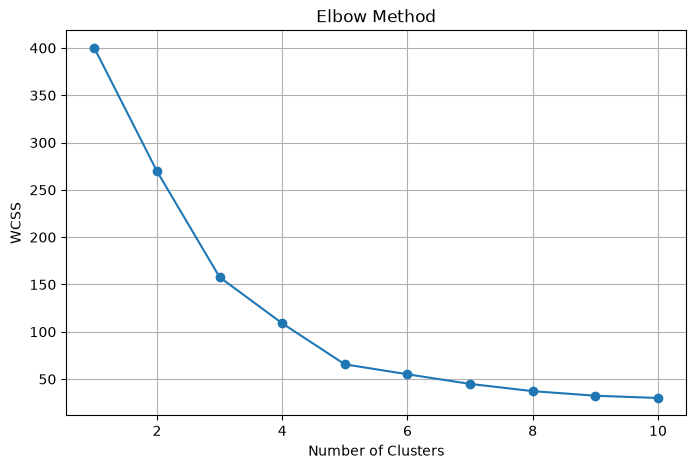

In [19]:
# Elbow Method

wcss = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

### Observation

The Elbow Method helps determine the optimal number of customer clusters.

The point where the curve begins to flatten represents the most suitable number of clusters for the dataset.

In [20]:
# Apply K-Means Clustering

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

print("Customer Segmentation Completed Successfully!")

df.head()

Customer Segmentation Completed Successfully!


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


### Observation

The K-Means clustering algorithm has successfully grouped customers into **5 distinct clusters** based on their Annual Income and Spending Score.

Each customer has been assigned a cluster label, which will be used for further analysis and visualization.

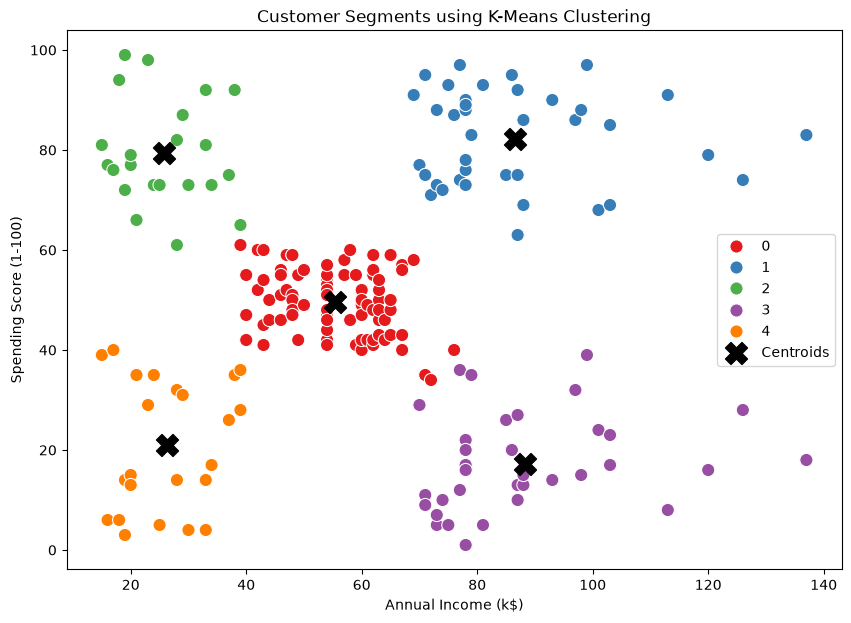

In [21]:
# Customer Segmentation Visualization

plt.figure(figsize=(10,7))

sns.scatterplot(
    x=df["Annual Income (k$)"],
    y=df["Spending Score (1-100)"],
    hue=df["Cluster"],
    palette="Set1",
    s=90
)

plt.scatter(
    scaler.inverse_transform(kmeans.cluster_centers_)[:,0],
    scaler.inverse_transform(kmeans.cluster_centers_)[:,1],
    color="black",
    marker="X",
    s=250,
    label="Centroids"
)

plt.title("Customer Segments using K-Means Clustering")

plt.xlabel("Annual Income (k$)")

plt.ylabel("Spending Score (1-100)")

plt.legend()

plt.show()

### Observation

The scatter plot clearly visualizes five customer segments formed using the K-Means clustering algorithm.

The black **X** markers represent the cluster centroids, while different colors indicate different customer groups based on annual income and spending behavior.

In [22]:
# Cluster Analysis

cluster_summary = df.groupby("Cluster")[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]].mean().round(2)

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.72,55.30,49.52
1,32.69,86.54,82.13
2,25.27,25.73,79.36
3,41.11,88.20,17.11
4,45.22,26.30,20.91


### Observation

The cluster summary provides the average age, annual income, and spending score for each customer segment.

These averages help interpret the characteristics of each cluster and understand differences in customer behavior.

In [23]:
# Customers in Each Cluster

cluster_count = df["Cluster"].value_counts().sort_index()

cluster_count

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

### Observation

The cluster count shows the number of customers assigned to each segment.

A balanced distribution indicates that the clustering algorithm has successfully partitioned customers into meaningful groups.

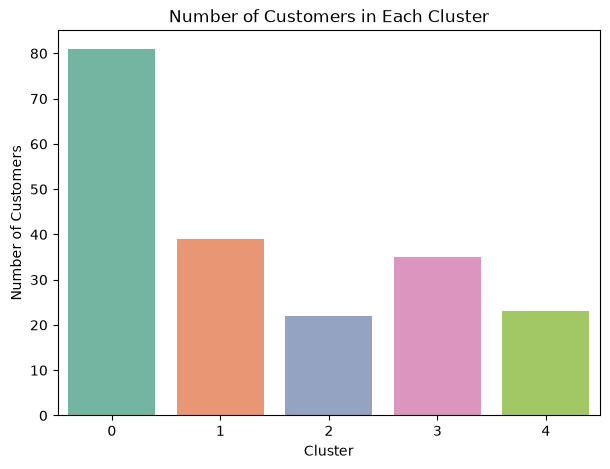

In [24]:
# Cluster Size Visualization

plt.figure(figsize=(7,5))

sns.countplot(
    x="Cluster",
    data=df,
    palette="Set2"
)

plt.title("Number of Customers in Each Cluster")

plt.xlabel("Cluster")

plt.ylabel("Number of Customers")

plt.show()

### Observation

The bar chart illustrates the number of customers present in each cluster.

This visualization helps compare the relative size of customer segments created by the K-Means algorithm.

In [25]:
# Final Data Summary

summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Total Features",
        "Missing Values",
        "Duplicate Records",
        "Selected Features",
        "Optimal Clusters",
        "Clustering Algorithm"
    ],
    "Value": [
        len(df),
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        "Annual Income & Spending Score",
        5,
        "K-Means"
    ]
})

summary

,Metric,Value
0,Total Customers,200
1,Total Features,6
2,Missing Values,0
3,Duplicate Records,0
4,Selected Features,Annual Income & Spending Score
5,Optimal Clusters,5
6,Clustering Algorithm,K-Means


### Observation

The final data summary provides an overview of the dataset and the clustering process.

The dataset consists of **200 customers** with no missing or duplicate records. Using **Annual Income** and **Spending Score** as the selected features, the K-Means algorithm successfully grouped customers into **five distinct segments**.

# Step 16: Conclusion

This project successfully developed a **Customer Segmentation System** using the **K-Means Clustering** algorithm.

The analysis began with data exploration, preprocessing, and visualization to better understand customer characteristics. Based on the Elbow Method, the optimal number of clusters was determined to be **five**, allowing customers to be grouped according to their annual income and spending behavior.

The resulting customer segments provide valuable insights into different purchasing patterns, enabling businesses to identify high-value customers, understand customer behavior, and design targeted marketing strategies.

Overall, this project demonstrates a complete end-to-end unsupervised machine learning workflow, from data preprocessing and exploratory analysis to clustering, visualization, and business interpretation.